# CMM 262: Introduction to Statistics, Day 2/2 Lecture Slide Plots

**Author**: Michelle Franc Ragsac (mragsac@ucsd.edu)

This notebook contains code to generate plots that were used in the lecture slides.

### Importing Packages of Interest

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The new additions for this week!
import numpy as np
import scipy.stats as stats

## Plotting the Binomial Probability Mass Function (PMF)

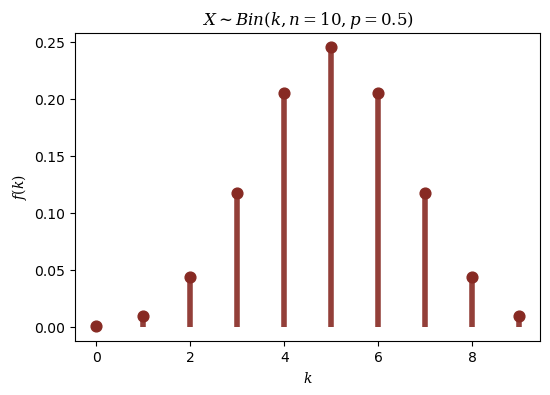

In [2]:
n = 10 # number of independent trials
k = np.arange(0, n, 1) # observed value of the random variable (number of successes)
p = 0.5 # probability

y = stats.binom.pmf(k, n, p)

c = "#872A23"

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.vlines(k, 0, y, colors=c, lw=4, alpha=0.9)
ax.scatter(k, y, marker="o", c=c, s=60)
ax.set_title(f"$X \\sim Bin(k,n={n},p={p})$", math_fontfamily="dejavuserif")
ax.set_xlabel("$k$", math_fontfamily="dejavuserif")
ax.set_ylabel("$f(k)$", math_fontfamily="dejavuserif")

plt.show()

## Plotting the Gaussian Probability Density Function (PDF)

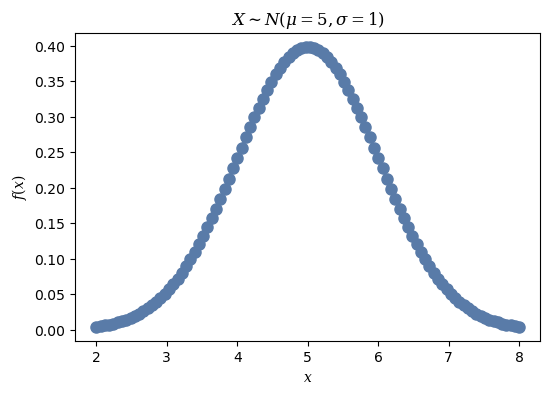

In [3]:
mu = 5 # mean
sigma = 1 # standard deviation
x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100) # range for x values

y = stats.norm.pdf(x, loc=mu, scale=sigma)

c = "#597BA8"

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(x, y, marker="o", color=c, lw=2, markersize=8)
ax.set_title(f"$X \\sim N(\\mu={mu},\\sigma={sigma})$", math_fontfamily="dejavuserif")
ax.set_xlabel("$x$", math_fontfamily="dejavuserif")
ax.set_ylabel("$f(x)$", math_fontfamily="dejavuserif")

plt.show()

## Plotting Confidence Intervals

In this segment, I'll be using data from the Palmer Penguins Dataset that we are also using for the interactive modules of this course.

In [4]:
df = pd.read_csv("data/penguins.csv", index_col=0)
df = df.dropna(subset="body_mass_g")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
6,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [5]:
# Generate "experimental" sampling data
num_sample = 50
num_trials = 1000
sample_means = []
for i in range(num_trials):
    sample_mass = df["body_mass_g"].sample(num_sample)
    sample_means.append(sample_mass.mean())

# Determine theoretical distribution
mu = df["body_mass_g"].mean()
se = df["body_mass_g"].std() / (num_sample ** (1 / 2))
x = np.arange(df["body_mass_g"].min(), df["body_mass_g"].max(), 10)
y = stats.norm.pdf(x, loc=mu, scale=se)

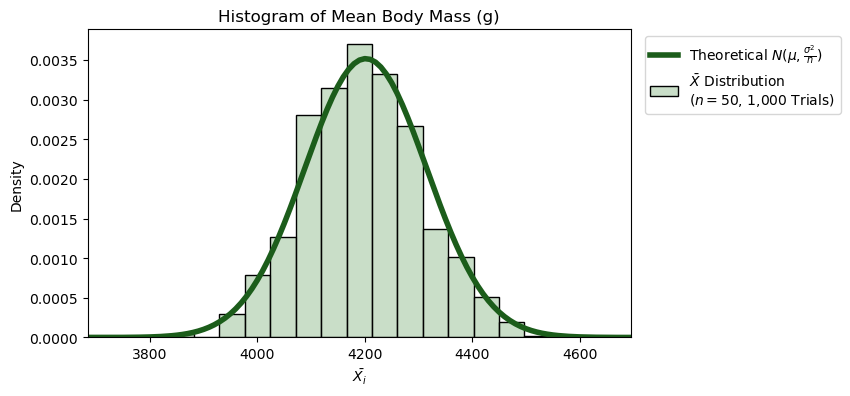

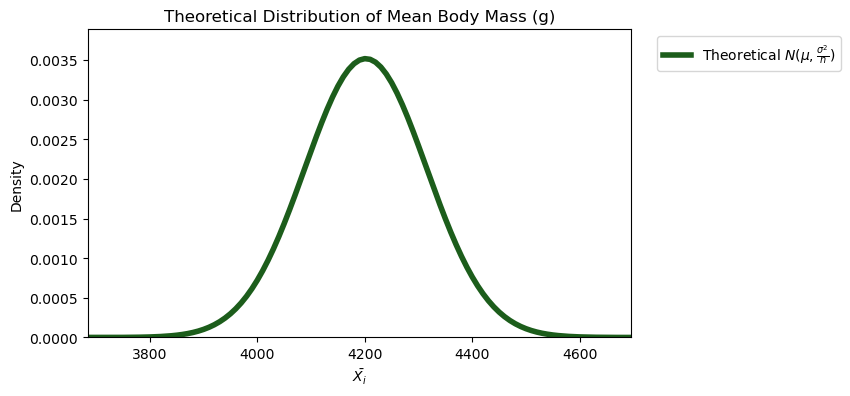

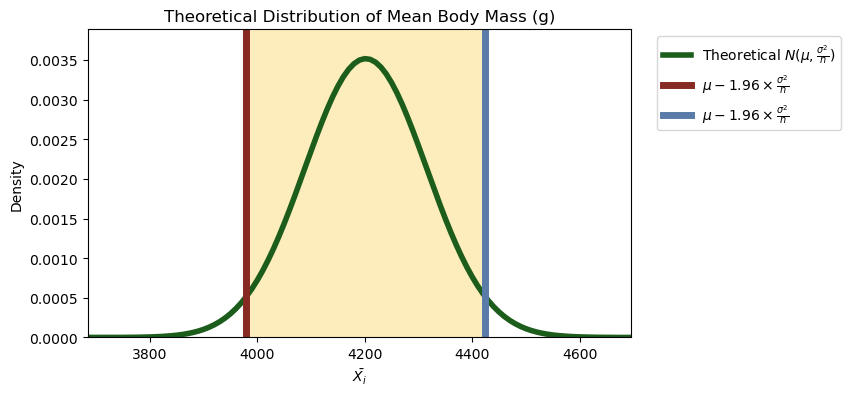

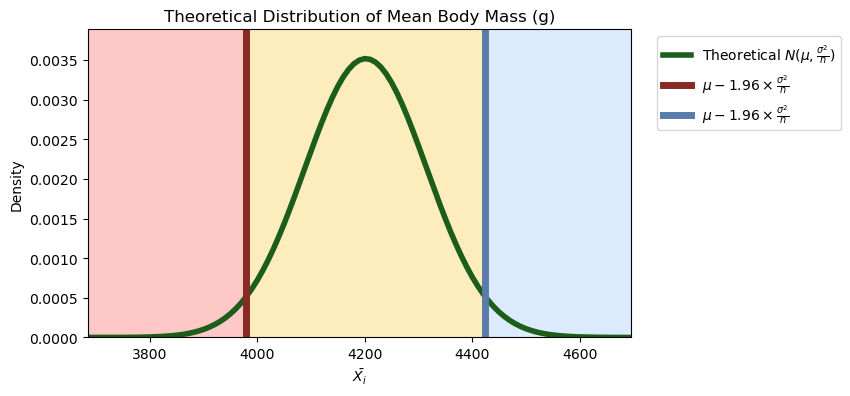

In [6]:
# Set shared parameters for plots
buffer = 150  # +/- buffer for the xlim values
bbox_to_anchor = (.9, 0.5, 0.5, 0.5)
figsize = (7, 4)

light_green = "#B7D4B6"
light_red = "#FDC8C5"
light_blue = "#DBEAFD"

yellow = "#FDEDBC"

dark_green = "#1C5D1B"
dark_red = "#872A23"
dark_blue = "#597BA8"

theoretical_title = r"Theoretical Distribution of Mean Body Mass (g)"
theoretical_label = r"Theoretical $N(\mu, \frac{\sigma^2}{n})$"

################################################################################
# Plot the histogram of sample means and the theoretical distribution
fig, ax = plt.subplots(1, 1, figsize=figsize)

label = r"$\bar{X}$ Distribution" "\n" f"($n={num_sample}$, 1,000 Trials)"
sns.histplot(sample_means, bins=15, stat="density", color=light_green, ax=ax, label=label)
ax.plot(x, y, color=dark_green, linewidth=4, label=theoretical_label)

old_xlim = (min(sample_means) - buffer, max(sample_means) + buffer)
old_ylim = ax.get_ylim()

ax.set_title(r"Histogram of Mean Body Mass (g)")
ax.set_xlabel(r"$\bar{X_i}$")
ax.set_ylabel("Density")
ax.set_xlim(old_xlim)

ax.legend(loc="best", bbox_to_anchor=bbox_to_anchor)
plt.show()

################################################################################
# Plot just the theoretical distribution
fig, ax = plt.subplots(1, 1, figsize=figsize)

ax.plot(x, y, color=dark_green, linewidth=4, label=theoretical_label)

ax.set_title(theoretical_title)
ax.set_xlabel(r"$\bar{X_i}$")
ax.set_ylabel("Density")
ax.set_xlim(old_xlim)
ax.set_ylim(old_ylim)

ax.legend(loc='best', bbox_to_anchor=bbox_to_anchor)
plt.show()

################################################################################
# Plot the theoretical distribution with the 95% confidence interval
fig, ax = plt.subplots(1, 1, figsize=figsize)

ax.plot(x, y, color=dark_green, linewidth=4, label=theoretical_label)

# 95% Confidence Interval
neg_label = r"$\mu - 1.96 \times \frac{\sigma^2}{n}$"
pos_label = r"$\mu - 1.96 \times \frac{\sigma^2}{n}$"
ax.axvline(mu - se * 1.96, color=dark_red, linewidth=5, label=neg_label)
ax.axvline(mu + se * 1.96, color=dark_blue, linewidth=5, label=pos_label)
ax.fill_between((mu - se * 1.96, mu + se * 1.96), 0, old_ylim[1], color=yellow)

ax.set_title(theoretical_title)
ax.set_xlabel(r"$\bar{X_i}$")
ax.set_ylabel("Density")
ax.set_xlim(old_xlim)
ax.set_ylim(old_ylim)

ax.legend(loc='best', bbox_to_anchor=bbox_to_anchor)
plt.show()

################################################################################
# Plot the theoretical distribution with the 95% confidence interval and tails
fig, ax = plt.subplots(1, 1, figsize=figsize)

ax.plot(x, y, color=dark_green, linewidth=4, label=theoretical_label)
ax.axvline(mu - se * 1.96, color=dark_red, linewidth=5, label=neg_label)
ax.axvline(mu + se * 1.96, color=dark_blue, linewidth=5, label=pos_label)
ax.fill_between((mu - se * 1.96, mu + se * 1.96), 0, old_ylim[1], color=yellow)

# New shadings added
ax.fill_between((old_xlim[0], mu - se * 1.96), 0, old_ylim[1], color=light_red)
ax.fill_between((mu + se * 1.96, old_xlim[1]), 0, old_ylim[1], color=light_blue)

ax.set_title(theoretical_title)
ax.set_xlabel(r"$\bar{X_i}$")
ax.set_ylabel("Density")
ax.set_xlim(old_xlim)
ax.set_ylim(old_ylim)

ax.legend(loc='best', bbox_to_anchor=bbox_to_anchor)
plt.show()
